In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.signal as signal
import scipy.fft as fft

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
#ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, RocCurveDisplay,auc
from sklearn.manifold import TSNE

from mice_utils import get_split_info,get_labels_subjects, get_sex_labels

import pickle
import shap



Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
strains = ('BXD87', 'DBA2', 'C57B6')
tscs = ('Het', 'WT')
sources = ('Jax_Lab','Nemours')
types = [strain+tsc for strain in strains for tsc in tscs ]
n_types = len(types)


mice_df = pd.read_pickle('meta-data/Jax_mice_with_splits_df.pickle')
nfolds,nsplits = get_split_info(mice_df)
print(nsplits,nfolds)


5 2


In [3]:
# Parameters for the segments used for testing
n_seg = 2880 # Number of segements per class 
n_seg_classifier = 480
# Parameters for the dictionary 
window_length = 256*2 # 2s
n_centroids = 200
centroid_len = 256
#n_multiplier = 10
#n_windows = int(n_centroids*20*n_multiplier) 
n_windows = 100000
n_windows = 40000
#str_si = 'sv_sph'
str_si = 'sv'

#pool_str = 'pooled'
pool_str = ''
use_spectral = False

if use_spectral:
    dict_param_string = 'spectral_'+str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)
else:
    dict_param_string = str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)+'_'+str(centroid_len)+'_'+str_si

In [4]:
from get_classifiers_by_split import consolidate_counts_subset



for split in range(nsplits):
    for test_fold in range(nfolds):
        print(f'Going to run consolidation on {split}{test_fold} {dict_param_string} {n_seg}')
        consolidate_counts_subset(test_fold, split,'test', dict_param_string, n_seg)


Going to run consolidation on 00 40000_512_200_256_sv 2880
Starting consolidate counts 0 0
Consolidated data ready!
Going to run consolidation on 01 40000_512_200_256_sv 2880
Starting consolidate counts 1 0
Consolidated data ready!
Going to run consolidation on 10 40000_512_200_256_sv 2880
Starting consolidate counts 0 1
Consolidated data ready!
Going to run consolidation on 11 40000_512_200_256_sv 2880
Starting consolidate counts 1 1
Consolidated data ready!
Going to run consolidation on 20 40000_512_200_256_sv 2880
Starting consolidate counts 0 2
Consolidated data ready!
Going to run consolidation on 21 40000_512_200_256_sv 2880
Starting consolidate counts 1 2
Consolidated data ready!
Going to run consolidation on 30 40000_512_200_256_sv 2880
Starting consolidate counts 0 3
Consolidated data ready!
Going to run consolidation on 31 40000_512_200_256_sv 2880
Starting consolidate counts 1 3
Consolidated data ready!
Going to run consolidation on 40 40000_512_200_256_sv 2880
Starting cons

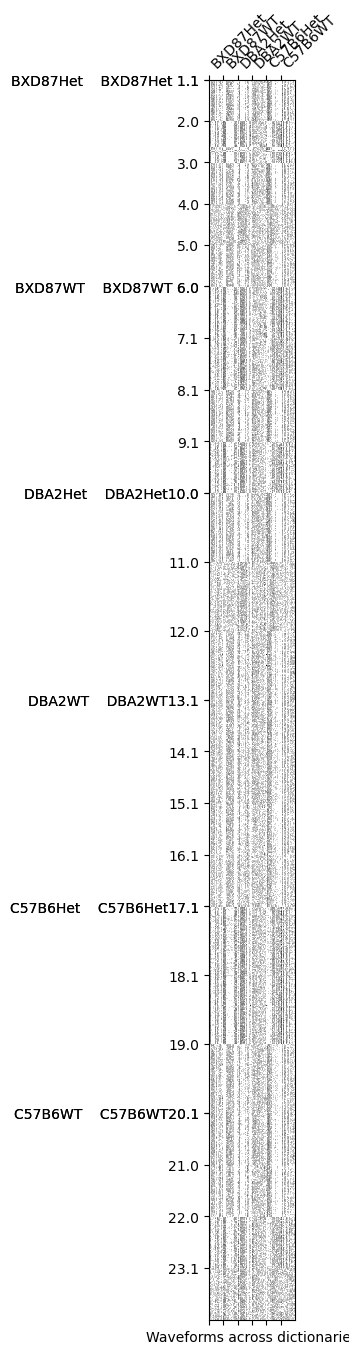

In [5]:
for split in range(1):#range(nsplits):
    for test_fold in range(1):#range(nfolds):
        segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
        segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
        count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
        counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
    
        label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
        sex_test,_,subject_index2namesex_test = get_sex_labels(mice_df, subject_test,subject_index2name_test)

        X_test = np.hstack( [ np.vstack( [np.array(counts_test[d,s]) for s in segment_info_test ] ) for d in segment_info_test])    

        label_string_list = [[str(s[-2])+str(s[-1])]*segment_info_test[s][0].shape[0]  for i,s in enumerate(segment_info_test)]

        sort_cols = lambda M : M[:,np.argsort(-np.sum(M,axis=0))]
        argsort_cols = lambda M : np.argsort(-np.sum(M,axis=0))
        
        col_sort_train = [ argsort_cols(np.vstack( [counts_test[d,s] for s in segment_info_test ] )) for d in segment_info_test]   
        count_matrix = np.hstack( [ sort_cols(np.vstack( [counts_test[d,s] for s in segment_info_test ] )) for d in segment_info_test])    
        
        
        dictionary_cards = np.array([ counts_test[d,d].shape[1]  for d in segment_info_test])    
        dictionary_starts = np.cumsum(np.concatenate(([0],dictionary_cards[:-1])))
        
    
        
        valid_count_matrix = np.hstack( [ np.vstack( [np.array(counts_test[d,s]) for s in segment_info_test ] )[:,col_sort_train[i]] for i,d in enumerate(segment_info_test)])            
        indices_sorted = np.argsort(subject_test).squeeze()
        test_subject_boundary = np.concatenate(([0],np.flatnonzero(np.diff(subject_test)!=0)))
        test_subject_labels = 1+np.unique(subject_test + sex_test/10)
        test_class_boundary = np.concatenate(([0],np.flatnonzero(np.diff(label_test)!=0)))
        test_class_labels = [types[int(x)] for x in np.unique(label_test)]
        test_merged_class_labels = [types[int(x)]+'    ' for x in np.unique(label_test)]
        isin = np.isin(test_subject_boundary,test_class_boundary)
        for i in range(len(test_class_labels)):
            match_idx = np.flatnonzero(test_subject_boundary == test_class_boundary[i])
            if len(match_idx)==1:
                app = str(test_subject_labels[match_idx].squeeze())
                test_merged_class_labels[i] += test_merged_class_labels[i][:-len(app)] + app
                
        plt.matshow(np.log(1+valid_count_matrix[indices_sorted]),cmap='gray_r')
        plt.xticks(dictionary_starts,labels=types,rotation=45,ha='left')
        plt.yticks(np.concatenate((test_subject_boundary,test_class_boundary)),
                   labels=np.concatenate((test_subject_labels,test_merged_class_labels)))
        plt.xlabel('Waveforms across dictionaries')
        plt.show()



In [6]:
def plot_confusion_matrix(y,y_pred,labels,title,fname,cmap="Blues"):
    conf_matrix = confusion_matrix(y, y_pred)
    micro_acc = np.trace(conf_matrix)/np.sum(conf_matrix)
    conf_matrix_norm = conf_matrix/ conf_matrix.sum(axis=1, keepdims=True)
#    macro_acc = np.mean(np.diag(conf_matrix_norm))
#    conf_matrix_norm *= 100
    fig = plt.figure()
    cs= plt.matshow(conf_matrix_norm,cmap=cmap,vmin=0,vmax=1)#00)

    scale_colormaps = {'Blues':-0.5,"Grays":-0.5,"hot":0.4}
    for (i, j), z in np.ndenumerate(conf_matrix_norm):
        if z==0:
            continue
        color = 'w'
        if np.sign(scale_colormaps[cmap])*z>scale_colormaps[cmap]:
            color = 'b'
        plt.text(j, i, '{:0.2f}'.format(z), ha='center', va='center',color=color)
    
    plt.colorbar(cs)
    plt.xticks(np.arange(len(labels)),labels=labels,rotation='vertical')
    plt.yticks(np.arange(len(labels)),labels=labels)
#    plt.title(f'Accuracy (%) {title}. Macro: {100*macro_acc:.0f}% Micro (n={len(y)}): {100*micro_acc:.0f}%')
    print(micro_acc)
    plt.title(f'Accuracy {title}: {micro_acc:.2f} (n={len(y)})')
#    plt.savefig(fname+'.eps', format='eps',bbox_inches='tight')
    plt.savefig('./results/'+fname+'.pdf', bbox_inches='tight')
    return fig


In [7]:
LOO = True

models/classifiers_l2_4800040000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4800140000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4801040000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4801140000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4802040000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4802140000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4803040000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4803140000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4804040000_512_200_256_svbg_on_strainLOO
models/classifiers_l2_4804140000_512_200_256_svbg_on_strainLOO
[0 0 0 ... 5 5 5]
0.6888888888888889
0.5629918981481481
0.6444444444444445
0.5602719907407407
0.6666666666666666
0.5861689814814814
0.6222222222222222
0.536400462962963
0.6
0.5349247685185186


<Figure size 640x480 with 0 Axes>

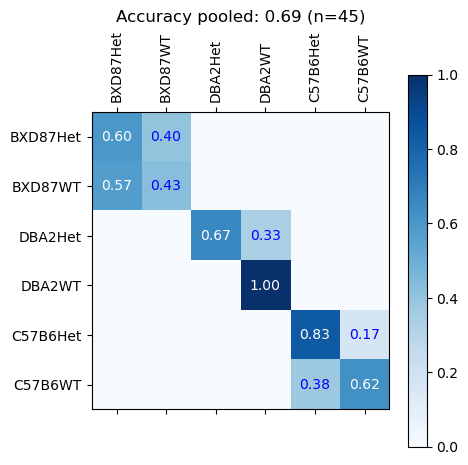

<Figure size 640x480 with 0 Axes>

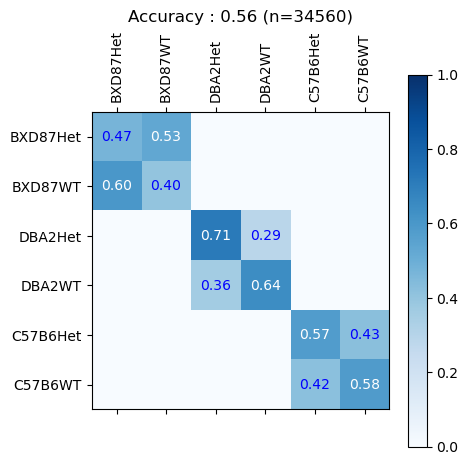

<Figure size 640x480 with 0 Axes>

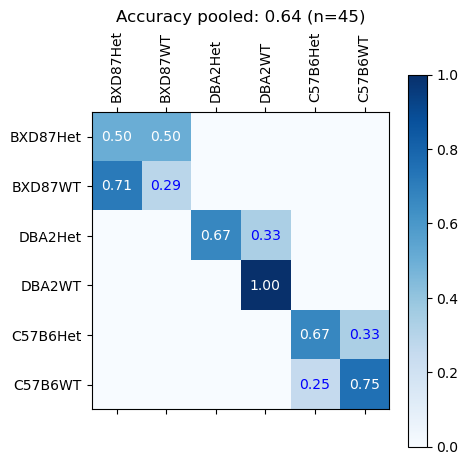

<Figure size 640x480 with 0 Axes>

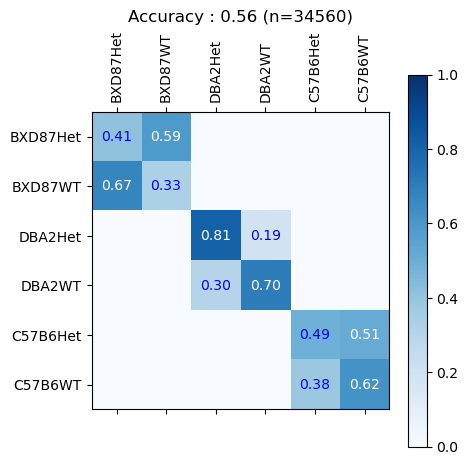

<Figure size 640x480 with 0 Axes>

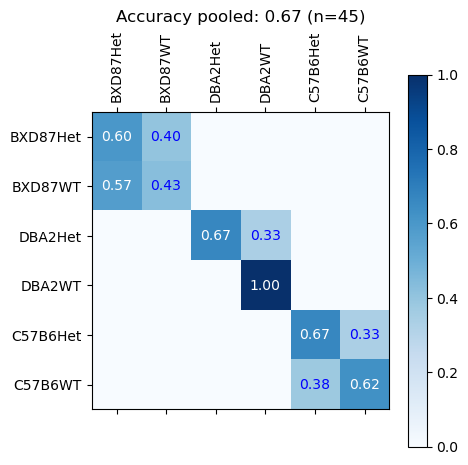

<Figure size 640x480 with 0 Axes>

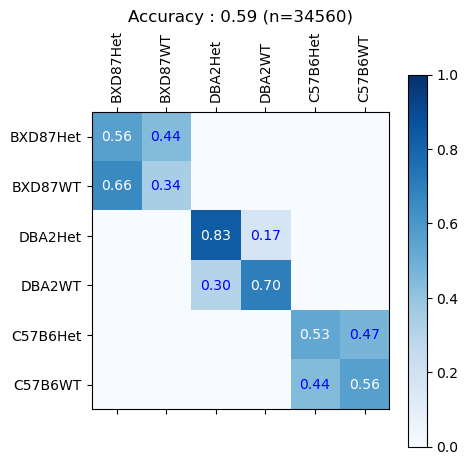

<Figure size 640x480 with 0 Axes>

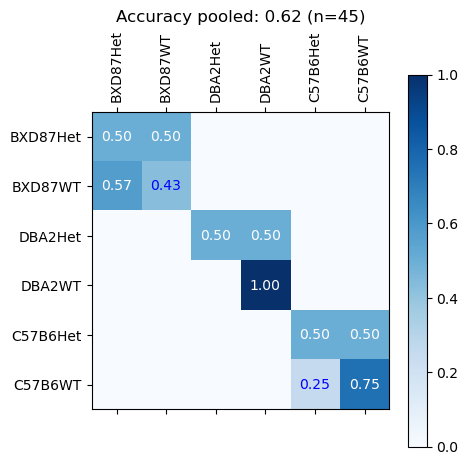

<Figure size 640x480 with 0 Axes>

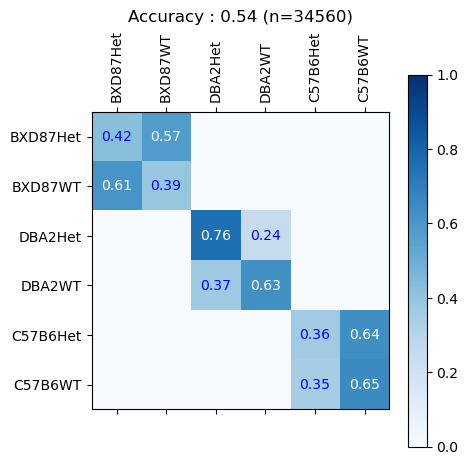

<Figure size 640x480 with 0 Axes>

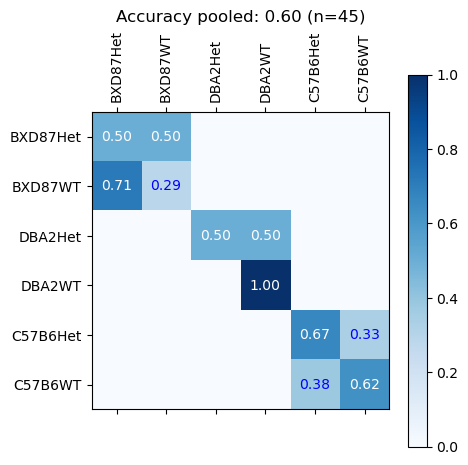

<Figure size 640x480 with 0 Axes>

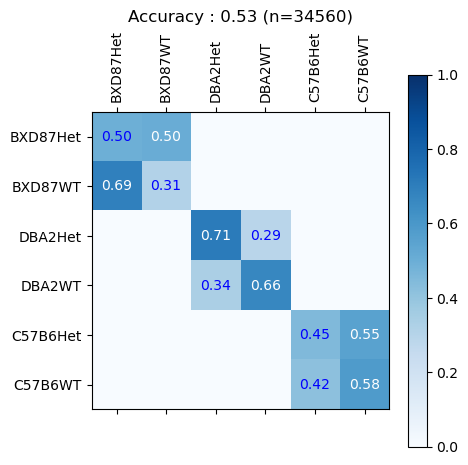

In [10]:
for task_str in ['tsc_on_strain']:#,'strain_on_tsc']:#,'tsc_on_strain']:
    all_pred = dict()
    all_pred_maj = dict()
    all_pred_pooled = dict()
    all_prob_pooled = dict()
    all_labels = dict()
    all_labels_pooled = dict()
    
    for split in range(nsplits):
        for test_fold in range(nfolds):
            segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
            segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
            count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
            classifier_count_param_string = str(n_seg_classifier)+str(split)+str(test_fold)+dict_param_string
            counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
        
            label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        

            subs_in_test, indices = np.unique(subject_test,return_index=True)
            y_test_pooled = label_test[indices].copy()        
            # Prepare prediction 
            y_pred = np.zeros_like(label_test)
            y_pred_maj = np.zeros_like(subs_in_test)
            y_pred_pooled = np.zeros_like(subs_in_test)
            y_prob_pooled = np.zeros(subs_in_test.shape)
    

            if task_str =='strain_on_tsc':
                given_test = label_test %  2
                cond_test = label_test // 2
                label_offset = label_test % 2
                label_offset_pooled = y_test_pooled % 2
                def label_remap(v):
                    return v*2
                set_of_given = np.arange(2)
            elif task_str =='tsc_on_strain':
                given_test = label_test //  2
                cond_test = label_test % 2                
                label_inv_map = given_test*2
                label_offset = (label_test // 2)*2
                label_offset_pooled = (y_test_pooled//2 )*2
                def label_remap(v):
                    return v
                set_of_given = np.arange(3)
    
            cond_test_pooled = cond_test[indices].copy()        
            X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    

            if LOO:
                n_groups = len(np.unique(subject_test))
            else:
                n_groups = 5

            group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
            # Load classifier
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+task_str+ 'LOO' if LOO else ''           
            print(filename)

            start_windows = np.concatenate([segment_info_test[s][0][:,2]  for i,s in enumerate(segment_info_test)])
            file_indices = np.concatenate([segment_info_test[s][0][:,1]  for i,s in enumerate(segment_info_test)])            
            mouse_id = subject_test 
            file_start_indices = np.concatenate(([0],1+np.flatnonzero((np.diff(file_indices)!=0) |(np.diff(mouse_id)!=0)   )))
            file_start_mouse_id = mouse_id[file_start_indices]
            file_start_label = label_test[file_start_indices]

            
            pipes = pickle.load(open(filename+".pkl", "rb")) 
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+ 'LOO' if LOO else ''           
            fold2pipe = pickle.load(open(filename+'_fold2pipe'+".pkl", "rb")) 
            

            for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):    
#                print([(i,j) for i,j in zip(orig_label[test_index],given_test[test_index])])
                given_labels = given_test[test_index]
                for given_label in set_of_given:
                    groups = subject_test[test_index[given_labels==given_label]]
                    subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
                    X = X_test[test_index[given_labels==given_label]]
                    if X.shape[0]==0:
                        continue
                    pipe_i = pipes[fold2pipe[subs_in_test[0]]][given_label]
                    y = cond_test[test_index[given_labels==given_label]]
                    
                
                    
                    y_pred[test_index[given_labels==given_label]] =  pipe_i.predict(X)
                    test_acc =  pipe_i.score(X,y) # each window independently 
                    for f in range(len(file_start_indices)-1):
                        curr_label = file_start_label[f]
                        curr_subject = file_start_mouse_id[f]
                        if curr_subject not in subs_in_test:
                            continue
                        one_file = range(file_start_indices[f],file_start_indices[f+1])
                        x = start_windows[one_file]/mice_df['sfreq'].iloc[0] 
                        x = x - np.min(x)
#                        print(x)
                        
                   # pooling counts per mouse 
                    ypooled = y[indices]
                    Xpooled = X[indices].copy()
                    for l,index in enumerate(indices):
                        Xpooled[l] = np.sum(X[inverses==l],axis=0)
                    
                    test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                    for sub in subs_in_test:
                        y_pred_pooled[sub] = pipe_i.predict(Xpooled[sub == subs_in_test])[0]
                        y_prob_pooled[sub] = pipe_i.predict_proba(Xpooled[sub == subs_in_test])[0,0]
            
            all_pred[split,test_fold] = label_remap(y_pred)+label_offset
            all_pred_pooled[split,test_fold] = label_remap(y_pred_pooled)+label_offset_pooled
            all_prob_pooled[split,test_fold] = y_prob_pooled.copy()
            all_labels_pooled[split,test_fold] = y_test_pooled.copy()
            all_labels[split,test_fold] = label_test.copy()
            
    
    print(all_labels[split,test_fold])
    for split in range(nsplits):
        y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
        y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
        y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_prob_pooled = np.concatenate([all_prob_pooled[split,test_fold] for test_fold in range(nfolds) ])
        run_name = pool_str+str(n_seg)+str(split)+dict_param_string
#        plot_confusion_matrix(y_test,y_pred,types,"average",task_str+run_name)

        plot_confusion_matrix(y_test_pooled,y_pred_pooled,types,"pooled",'tsc_given_bg'+run_name+"_pooled")
        
        plot_confusion_matrix(y_test,y_pred,types,"",'tsc_given_bg'+run_name+"")
        # plot_confusion_matrix(y_test_pooled,y_pred_maj,types,"maj.",'tsc_given_bg'+run_name+"_maj")
        # if split>0:
        #     plt.close()
        np.savez('./results/'+'tsc_given_bg'+run_name,y_test_pooled=y_test_pooled,y_prob_pooled=y_prob_pooled)        


In [11]:
# tf_method = lambda x: pipe_i.named_steps['tfidf'].transform(x)
# print(tf_method(np.hstack((np.ones((1,600)),np.zeros((1,600)))))[0,0:8])
# print(tf_method(np.hstack((60*np.ones((1,600)),np.zeros((1,600)))))[0,0:8])

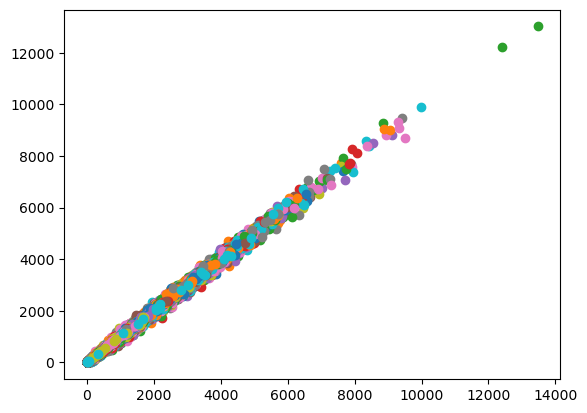

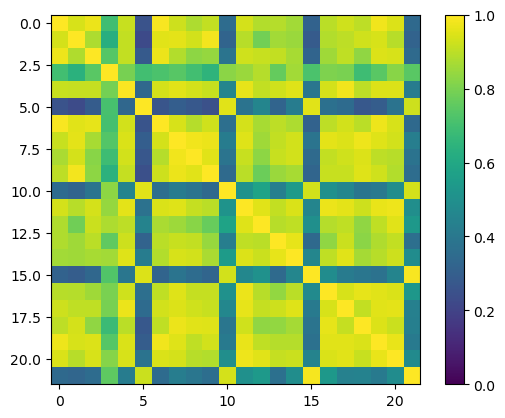

In [12]:
# compare the two sets

Xpooled = np.zeros((len(np.unique(subject_test)),1200,2))
Xpooled = np.zeros((len(np.unique(subject_test)),1200,2))

for do_twice, a_seg in enumerate([n_seg,n_seg_classifier]):
    count_param_string = str(a_seg)+str(split)+str(test_fold)+dict_param_string
    segment_param_string = str(a_seg)+'_'+str(split)+str(test_fold)+dict_param_string        

    counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
    segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
       
    label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        

    subs_in_test, indices, inverses = np.unique(subject_test,return_index=True, return_inverse=True)
    X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
    # 60 minute 
    
    for l,index in enumerate(indices):
        Xpooled[l,:,do_twice] = np.sum(X_test[inverses==l],axis=0)


#plt.plot(np.log(10+np.hstack((Xpooled[:,:,0],Xpooled[:,:,1]))).T)
plt.plot(Xpooled[:,:,0],Xpooled[:,:,1],'o')
plt.show()

nXpooled = Xpooled/np.sqrt(np.sum(Xpooled**2,axis=1,keepdims=True))
plt.imshow(nXpooled[:,:,0]@nXpooled[:,:,1].T,cmap='viridis',vmax=1,vmin=0)
plt.colorbar()
plt.show()


models/classifiers_l2_4800040000_512_200_256_svstrainLOO
models/classifiers_l2_4800140000_512_200_256_svstrainLOO
models/classifiers_l2_4801040000_512_200_256_svstrainLOO
models/classifiers_l2_4801140000_512_200_256_svstrainLOO
models/classifiers_l2_4802040000_512_200_256_svstrainLOO
models/classifiers_l2_4802140000_512_200_256_svstrainLOO
models/classifiers_l2_4803040000_512_200_256_svstrainLOO
models/classifiers_l2_4803140000_512_200_256_svstrainLOO
models/classifiers_l2_4804040000_512_200_256_svstrainLOO
models/classifiers_l2_4804140000_512_200_256_svstrainLOO
0.540625
0.7111111111111111
0.5372974537037037
0.6666666666666666
0.543605324074074
0.7111111111111111
0.5275173611111111
0.7111111111111111
0.5372685185185185
0.6888888888888889


<Figure size 640x480 with 0 Axes>

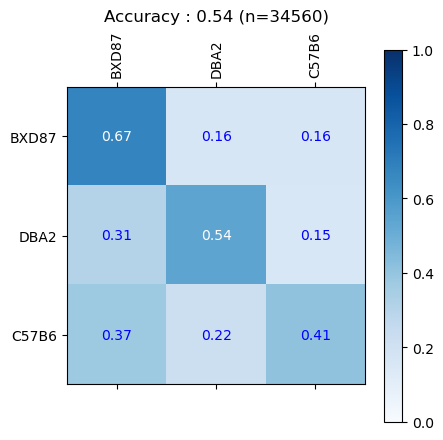

<Figure size 640x480 with 0 Axes>

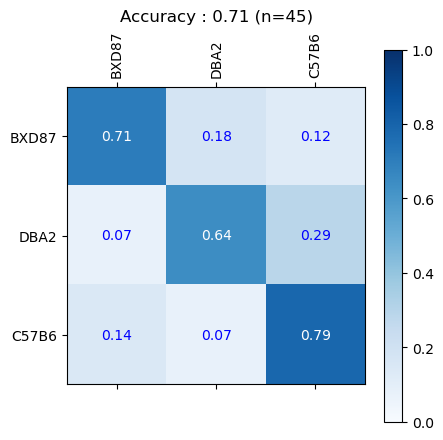

<Figure size 640x480 with 0 Axes>

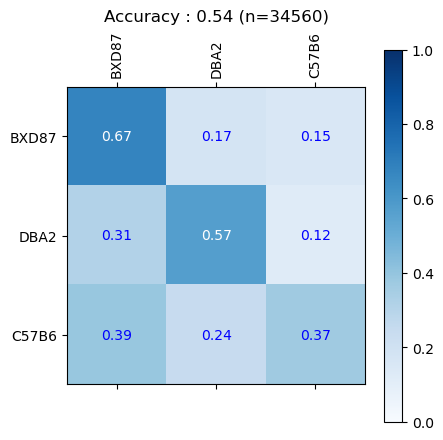

<Figure size 640x480 with 0 Axes>

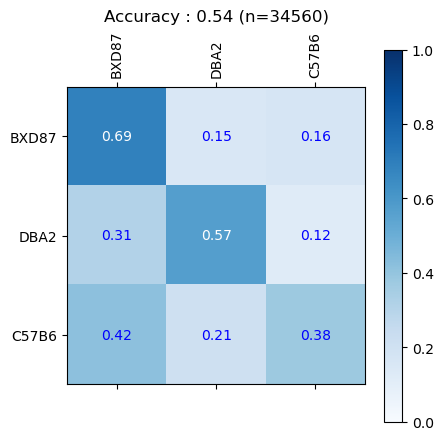

<Figure size 640x480 with 0 Axes>

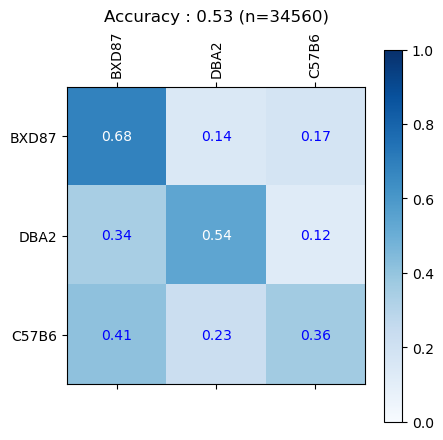

<Figure size 640x480 with 0 Axes>

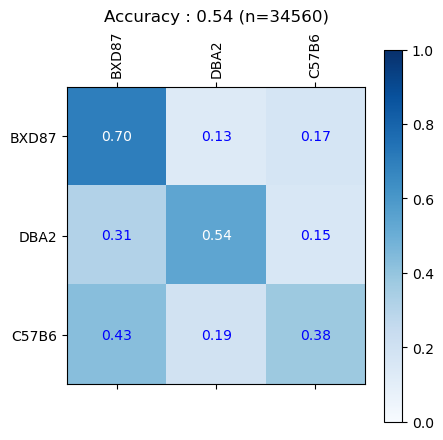

In [14]:
for task_str in ['strain']:
    all_pred = dict()
    all_pred_maj = dict()
    all_pred_pooled = dict()
    all_labels = dict()
    all_labels_pooled = dict()
    
    for split in range(nsplits):
        for test_fold in range(nfolds):
            segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string     
            classifier_count_param_string = str(n_seg_classifier)+str(split)+str(test_fold)+dict_param_string
            
#            segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
#            _,_,subject_index2name = get_labels_subjects(segment_info_train)
            segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
            count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
            counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
            label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
            X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
            # Load classifier
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+task_str+ 'LOO' if LOO else ''
#            filename = 'models/hpc_classifiers_across_folds_l2_'+count_param_string+task_str+ 'LOO' if LOO else ''
            print(filename)
            pipes = pickle.load(open(filename+".pkl", "rb")) 
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+ 'LOO' if LOO else ''           
            fold2pipe = pickle.load(open(filename+'_fold2pipe'+".pkl", "rb")) 
    
            # Prepare prediction 
            if task_str =='type':
                y_all = label_test.copy()
            elif task_str =='strain':
                y_all = label_test // 2
            elif task_str =='tsc':
                y_all = label_test % 2
            
            y_pred = np.zeros_like(y_all)
            subs_in_test, indices = np.unique(subject_test,return_index=True)
            y_test_pooled = y_all[indices]        
            y_pred_maj = np.zeros_like(subs_in_test)
            y_pred_pooled = np.zeros_like(subs_in_test)
    
            all_labels[split,test_fold] = y_all.copy()
            all_labels_pooled[split,test_fold] = y_test_pooled.copy()
            
            if LOO:
                n_groups = len(np.unique(subject_test))
            else:
                n_groups = 5
                # two fold based on dictionary (done 5 random splits)
                # five fold on the test
                # Together this is
                # 1/2 + 4/5*1/2 = 5/10+4/10 = 9/10 of mice in training, 1/5*1/2 = 1/10 of mice test
                # for each dictionary we get results for 1/2 mice in test
            group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
            
            for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
                X = X_test[test_index]
                y = y_all[test_index]
                
                groups = subject_test[test_index]
                subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
                pipe_i = pipes[fold2pipe[subs_in_test[0]]]
                
                y_pred[test_index] =  pipe_i.predict(X)
                test_acc =  pipe_i.score(X,y) # each window independently 
    
               # pooling counts per mouse 
                ypooled = y[indices]
                Xpooled = X[indices].copy()
                for l,index in enumerate(indices):
                    Xpooled[l] = np.sum(X[inverses==l],axis=0)
                
                test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                for sub in subs_in_test:
                    y_pred_pooled[sub] = pipe_i.predict(Xpooled[sub == subs_in_test])[0]
            
                for l,index in enumerate(indices):
                    sub = subs_in_test[l]
                    y_pred_maj[sub] = np.argmax(np.sum(pipe_i.predict_log_proba(X[inverses==l]),axis=0))
                
                test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
#                print(f"Fold {k}: C={pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
#                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
            all_pred[split,test_fold] = y_pred.copy()
            all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
            all_pred_maj[split,test_fold] = y_pred_maj.copy()
    
    
    for split in range(nsplits):
        y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
        y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
        y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_maj = np.concatenate([all_pred_maj[split,test_fold] for test_fold in range(nfolds) ])
        
        run_name = str(n_seg)+pool_str+str(split)+dict_param_string
        if task_str=='type':     
            the_labels = types
            file_prefix = 'type'
        elif task_str=='strain':
            the_labels = strains
            file_prefix = 'tsc'
        elif task_str=='tsc':
            the_labels = tscs
            file_prefix = 'tsc'
        fig1=plot_confusion_matrix(y_test,y_pred,the_labels,"",file_prefix+run_name+"")
        fig2=plot_confusion_matrix(y_test_pooled,y_pred_pooled,the_labels,"",file_prefix+run_name+"pooled")
#        fig2=plot_confusion_matrix(y_test_pooled,y_pred_maj,the_labels,"maj.",file_prefix+run_name+"_maj")
#        plot_confusion_matrix(y_test,y_pred,the_labels,"ave 1 hour",task_str+run_name)
        if split>0:
            plt.close()
            plt.close()       

In [ ]:
for task_str in ['type']:
    all_pred = dict()
    all_pred_maj = dict()
    all_pred_pooled = dict()
    all_labels = dict()
    all_labels_pooled = dict()
    
    for split in range(nsplits):
        for test_fold in range(nfolds):
            segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string     
            classifier_count_param_string = str(n_seg_classifier)+str(split)+str(test_fold)+dict_param_string
            
#            segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
#            _,_,subject_index2name = get_labels_subjects(segment_info_train)
            segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
            count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
            counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
            label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
            X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
            # Load classifier
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+task_str+ 'LOO' if LOO else ''
#            filename = 'models/hpc_classifiers_across_folds_l2_'+count_param_string+task_str+ 'LOO' if LOO else ''
            print(filename)
            pipes = pickle.load(open(filename+".pkl", "rb")) 
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+ 'LOO' if LOO else ''           
            fold2pipe = pickle.load(open(filename+'_fold2pipe'+".pkl", "rb")) 
    
            # Prepare prediction 
            if task_str =='type':
                y_all = label_test.copy()
            elif task_str =='strain':
                y_all = label_test // 2
            elif task_str =='tsc':
                y_all = label_test % 2
            
            y_pred = np.zeros_like(y_all)
            subs_in_test, indices = np.unique(subject_test,return_index=True)
            y_test_pooled = y_all[indices]        
            y_pred_maj = np.zeros_like(subs_in_test)
            y_pred_pooled = np.zeros_like(subs_in_test)
    
            all_labels[split,test_fold] = y_all.copy()
            all_labels_pooled[split,test_fold] = y_test_pooled.copy()
            
            if LOO:
                n_groups = len(np.unique(subject_test))
            else:
                n_groups = 5
                # two fold based on dictionary (done 5 random splits)
                # five fold on the test
                # Together this is
                # 1/2 + 4/5*1/2 = 5/10+4/10 = 9/10 of mice in training, 1/5*1/2 = 1/10 of mice test
                # for each dictionary we get results for 1/2 mice in test
            group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
            
            for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
                X = X_test[test_index]
                y = y_all[test_index]
                
                groups = subject_test[test_index]
                subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
            
                pipe_i = pipes[[fold2pipe[subs_in_test[0]]]]
                
                y_pred[test_index] =  pipe_i.predict(X)
                test_acc =  pipe_i.score(X,y) # each window independently 
    
               # pooling counts per mouse 
                ypooled = y[indices]
                Xpooled = X[indices].copy()
                for l,index in enumerate(indices):
                    Xpooled[l] = np.sum(X[inverses==l],axis=0)
                
                test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                for sub in subs_in_test:
                    y_pred_pooled[sub] = pipe_i.predict(Xpooled[sub == subs_in_test])[0]
            
                for l,index in enumerate(indices):
                    sub = subs_in_test[l]
                    y_pred_maj[sub] = np.argmax(np.sum(pipe_i.predict_log_proba(X[inverses==l]),axis=0))
                
                test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
#                print(f"Fold {k}: C={pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
#                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
            all_pred[split,test_fold] = y_pred.copy()
            all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
            all_pred_maj[split,test_fold] = y_pred_maj.copy()
    
    
    for split in range(nsplits):
        y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
        y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
        y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_maj = np.concatenate([all_pred_maj[split,test_fold] for test_fold in range(nfolds) ])
        
        run_name = str(n_seg)+pool_str+str(split)+dict_param_string
        if task_str=='type':     
            the_labels = types
            file_prefix = 'type'
        elif task_str=='strain':
            the_labels = strains
            file_prefix = 'tsc'
        elif task_str=='tsc':
            the_labels = tscs
            file_prefix = 'tsc'
        fig1=plot_confusion_matrix(y_test,y_pred,the_labels,"",file_prefix+run_name+"")
        fig2=plot_confusion_matrix(y_test_pooled,y_pred_pooled,the_labels,"",file_prefix+run_name+"pooled")
#        fig2=plot_confusion_matrix(y_test_pooled,y_pred_maj,the_labels,"maj.",file_prefix+run_name+"_maj")
#        plot_confusion_matrix(y_test,y_pred,the_labels,"ave 1 hour",task_str+run_name)
        if split>0:
            plt.close()
            plt.close()       

In [ ]:
for task_str in ['type']:
    all_pred = dict()
    all_pred_maj = dict()
    all_pred_pooled = dict()
    all_labels = dict()
    all_labels_pooled = dict()
    
    for split in range(nsplits):
        for test_fold in range(nfolds):
            segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string     
            classifier_count_param_string = str(n_seg_classifier)+str(split)+str(test_fold)+dict_param_string
            
#            segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
#            _,_,subject_index2name = get_labels_subjects(segment_info_train)
            segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
            count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
            counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
            label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
            X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
            # Load classifier
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+task_str+ 'LOO' if LOO else ''
#            filename = 'models/hpc_classifiers_across_folds_l2_'+count_param_string+task_str+ 'LOO' if LOO else ''
            print(filename)
            pipes = pickle.load(open(filename+".pkl", "rb")) 
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+ 'LOO' if LOO else ''           
            fold2pipe = pickle.load(open(filename+'_fold2pipe'+".pkl", "rb")) 
    
            # Prepare prediction 
            if task_str =='type':
                y_all = label_test.copy()
            elif task_str =='strain':
                y_all = label_test // 2
            elif task_str =='tsc':
                y_all = label_test % 2
            
            y_pred = np.zeros_like(y_all)
            subs_in_test, indices = np.unique(subject_test,return_index=True)
            y_test_pooled = y_all[indices]        
            y_pred_maj = np.zeros_like(subs_in_test)
            y_pred_pooled = np.zeros_like(subs_in_test)
    
            all_labels[split,test_fold] = y_all.copy()
            all_labels_pooled[split,test_fold] = y_test_pooled.copy()
            
            if LOO:
                n_groups = len(np.unique(subject_test))
            else:
                n_groups = 5
                # two fold based on dictionary (done 5 random splits)
                # five fold on the test
                # Together this is
                # 1/2 + 4/5*1/2 = 5/10+4/10 = 9/10 of mice in training, 1/5*1/2 = 1/10 of mice test
                # for each dictionary we get results for 1/2 mice in test
            group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
            
            for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
                X = X_test[test_index]
                y = y_all[test_index]
                
                groups = subject_test[test_index]
                subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
            
                pipe_i = pipes[[fold2pipe[subs_in_test[0]]]]
                
                y_pred[test_index] =  pipe_i.predict(X)
                test_acc =  pipe_i.score(X,y) # each window independently 
    
               # pooling counts per mouse 
                ypooled = y[indices]
                Xpooled = X[indices].copy()
                for l,index in enumerate(indices):
                    Xpooled[l] = np.sum(X[inverses==l],axis=0)
                
                test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                for sub in subs_in_test:
                    y_pred_pooled[sub] = pipe_i.predict(Xpooled[sub == subs_in_test])[0]
            
                for l,index in enumerate(indices):
                    sub = subs_in_test[l]
                    y_pred_maj[sub] = np.argmax(np.sum(pipe_i.predict_log_proba(X[inverses==l]),axis=0))
                
                test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
#                print(f"Fold {k}: C={pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
#                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
            all_pred[split,test_fold] = y_pred.copy()
            all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
            all_pred_maj[split,test_fold] = y_pred_maj.copy()
    
    
    for split in range(nsplits):
        y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
        y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
        y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_maj = np.concatenate([all_pred_maj[split,test_fold] for test_fold in range(nfolds) ])
        
        run_name = str(n_seg)+pool_str+str(split)+dict_param_string
        if task_str=='type':     
            the_labels = types
            file_prefix = 'type'
        elif task_str=='strain':
            the_labels = strains
            file_prefix = 'tsc'
        elif task_str=='tsc':
            the_labels = tscs
            file_prefix = 'tsc'
        plot_confusion_matrix(y_test_pooled%2,y_pred_pooled%2,tscs,"pooled",'indep'+'_tsc_'+task_str+run_name+"_pooled")
        if split>0:
            plt.close()       

In [ ]:
for task_str in ['tsc']:
    all_pred = dict()
    all_pred_maj = dict()
    all_pred_pooled = dict()
    all_labels = dict()
    all_labels_pooled = dict()
    all_prob_pooled = dict()
    
    for split in range(nsplits):
        for test_fold in range(nfolds):
            segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string     
            classifier_count_param_string = str(n_seg_classifier)+str(split)+str(test_fold)+dict_param_string            
#            segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
#            _,_,subject_index2name = get_labels_subjects(segment_info_train)
            segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
            count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
            counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
            label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
            X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
            # Load classifier
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+task_str+ 'LOO' if LOO else ''
#            filename = 'models/hpc_classifiers_across_folds_l2_'+count_param_string+task_str+ 'LOO' if LOO else ''
            print(filename)
            pipes = pickle.load(open(filename+".pkl", "rb")) 
            filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+ 'LOO' if LOO else ''           
            fold2pipe = pickle.load(open(filename+'_fold2pipe'+".pkl", "rb")) 
    
            # Prepare prediction 
            if task_str =='type':
                y_all = label_test.copy()
            elif task_str =='strain':
                y_all = label_test // 2
            elif task_str =='tsc':
                y_all = label_test % 2
            
            y_pred = np.zeros_like(y_all)
            subs_in_test, indices = np.unique(subject_test,return_index=True)
            y_test_pooled = y_all[indices]        
            y_pred_maj = np.zeros_like(subs_in_test)
            y_pred_pooled = np.zeros_like(subs_in_test)
            y_prob_pooled = np.zeros(subs_in_test.shape)

            all_labels[split,test_fold] = y_all.copy()
            all_labels_pooled[split,test_fold] = y_test_pooled.copy()
            
            if LOO:
                n_groups = len(np.unique(subject_test))
            else:
                n_groups = 5
                # two fold based on dictionary (done 5 random splits)
                # five fold on the test
                # Together this is
                # 1/2 + 4/5*1/2 = 5/10+4/10 = 9/10 of mice in training, 1/5*1/2 = 1/10 of mice test
                # for each dictionary we get results for 1/2 mice in test
            group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
            
            for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
                X = X_test[test_index]
                y = y_all[test_index]
                
                groups = subject_test[test_index]
                subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
            
                pipe_i = pipes[[fold2pipe[subs_in_test[0]]]]
                
                y_pred[test_index] =  pipe_i.predict(X)
                test_acc =  pipe_i.score(X,y) # each window independently 
    
               # pooling counts per mouse 
                ypooled = y[indices]
                Xpooled = X[indices].copy()
                for l,index in enumerate(indices):
                    Xpooled[l] = np.sum(X[inverses==l],axis=0)
                
                test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                for sub in subs_in_test:
                    y_pred_pooled[sub] = pipe_i.predict(Xpooled[sub == subs_in_test])[0]
                    y_prob_pooled[sub] = pipe_i.predict_proba(Xpooled[sub == subs_in_test])[0,0]
            
                for l,index in enumerate(indices):
                    sub = subs_in_test[l]
                    y_pred_maj[sub] = np.argmax(np.sum(pipe_i.predict_log_proba(X[inverses==l]),axis=0))
                
                test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
#                print(f"Fold {k}: C={pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
#                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
            all_pred[split,test_fold] = y_pred.copy()
            all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
            all_pred_maj[split,test_fold] = y_pred_maj.copy()
            all_prob_pooled[split,test_fold] = y_prob_pooled.copy()
    
    for split in range(nsplits):
        y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
        y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
        y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_maj = np.concatenate([all_pred_maj[split,test_fold] for test_fold in range(nfolds) ])
        y_prob_pooled = np.concatenate([all_prob_pooled[split,test_fold] for test_fold in range(nfolds) ])

        run_name = str(n_seg)+pool_str+str(split)+dict_param_string
        if task_str=='type':     
            the_labels = types
            file_prefix = 'type'
        elif task_str=='strain':
            the_labels = strains
            file_prefix = 'tsc'
        elif task_str=='tsc':
            the_labels = tscs
            file_prefix = 'tsc'
        fig1=plot_confusion_matrix(y_test,y_pred,the_labels,"",file_prefix+run_name+"")
        fig2=plot_confusion_matrix(y_test_pooled,y_pred_pooled,the_labels,"",file_prefix+run_name+"pooled")
        np.savez('./results/'+file_prefix+run_name,y_test_pooled=y_test_pooled,y_prob_pooled=y_prob_pooled)        
        
#        fig2=plot_confusion_matrix(y_test_pooled,y_pred_maj,the_labels,"maj.",file_prefix+run_name+"_maj")
#        plot_confusion_matrix(y_test,y_pred,the_labels,"ave 1 hour",task_str+run_name)
        if split>0:
            plt.close()
            plt.close()       

In [ ]:
all_pred = dict()
all_pred_maj = dict()
all_pred_pooled = dict()
all_labels = dict()
all_labels_pooled = dict()

task_str = 'type'

for split in range(nsplits):
    for test_fold in range(nfolds):
        segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
        segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
        classifier_count_param_string = str(n_seg_classifier)+str(split)+str(test_fold)+dict_param_string            
        count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
        counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
    
        label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
 
        X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    

        # Load classifier
        filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+'strain'+ 'LOO' if LOO else ''
        print(filename)
        strain_pipes = pickle.load(open(filename+".pkl", "rb")) 

        filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+'tsc_on_strain'+ 'LOO' if LOO else ''
        print(filename)
        bg_cond_pipes = pickle.load(open(filename+".pkl", "rb")) 

        filename = 'models/classifiers_l2_'+pool_str+classifier_count_param_string+ 'LOO' if LOO else ''           
        fold2pipe = pickle.load(open(filename+'_fold2pipe'+".pkl", "rb")) 

        # Prepare prediction 
        y_pred = np.zeros_like(label_test)
        subs_in_test, indices = np.unique(subject_test,return_index=True)
        y_test_pooled = label_test[indices].copy()       # first of each
        y_pred_maj = np.zeros_like(subs_in_test)
        y_pred_pooled = np.zeros_like(subs_in_test)

        all_labels[split,test_fold] = label_test.copy()
        all_labels_pooled[split,test_fold] = y_test_pooled.copy()
        
        if LOO:
            n_groups = len(np.unique(subject_test))
        else:
            n_groups = 5
        group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
        
        for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
            X = X_test[test_index]
            y = label_test[test_index]
            groups = subject_test[test_index]
            subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
        
            strain_pipe_i = strain_pipes[[fold2pipe[subs_in_test[0]]]]
            bg_cond_pipes_i = bg_cond_pipes[[fold2pipe[subs_in_test[0]]]]
            def joined_predict(X):
                strain_predict = strain_pipe_i.predict(X)
                conditional_bg_predict = np.vstack([bg_cond_pipes_i[l].predict(X) for l in range(3)])
                return 2*strain_predict + conditional_bg_predict[strain_predict,np.arange(X.shape[0])].reshape(strain_predict.shape) 
# oracle case for sanity 
            def joined_predict_oracle(X,true_strain):
                conditional_bg_predict = np.vstack([bg_cond_pipes_i[l].predict(X) for l in range(3)])
                return 2*true_strain + conditional_bg_predict[true_strain,np.arange(X.shape[0])].reshape(true_strain.shape) 
            
            def joined_log_proba(X):
                conditional_bg_log_proba = np.hstack([bg_cond_pipes_i[l].predict_log_proba(X) for l in range(3)])
                return np.kron(strain_pipe_i.predict_log_proba(X),np.ones((1,2))) + conditional_bg_log_proba

            # def joined_log_proba(X):
            #     strain_predict = strain_pipe_i.predict(X)
            #     conditional_bg_log_proba = np.hstack([bg_cond_pipes_i[l].predict_log_proba(X) for l in range(3)])
            #     return 1*(strain_predict[:,np.newaxis]==np.kron(np.arange(3),np.ones((1,2))))  + conditional_bg_log_proba
                
            
            y_pred[test_index] = joined_predict(X)
#            y_pred[test_index] = joined_predict_oracle(X,y//2)

            test_acc =  np.mean(y==y_pred[test_index]) # each window independently 
            
           # pooling counts per mouse 
            ypooled = y[indices]
            Xpooled = X[indices].copy()
            for l,index in enumerate(indices):
                Xpooled[l] = np.sum(X[inverses==l],axis=0)
            
            test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
            for sub_i,sub in enumerate(subs_in_test):
#                y_pred_pooled[sub] = joined_predict_oracle(Xpooled[sub == subs_in_test],ypooled[[sub_i]]//2)[0]
                y_pred_pooled[sub] = joined_predict(Xpooled[sub == subs_in_test])[0]
        
            for l,index in enumerate(indices):
                sub = subs_in_test[l]
                y_pred_maj[sub] = np.argmax(np.sum(joined_log_proba(X[inverses==l]),axis=0))
            
            test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
#            print(f"Fold {k}: C={strain_pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
#                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
        all_pred[split,test_fold] = y_pred.copy()
        all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
        all_pred_maj[split,test_fold] = y_pred_maj.copy()


for split in range(nsplits):
    y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
    y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
    y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
    y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
    y_pred_maj = np.concatenate([all_pred_maj[split,test_fold] for test_fold in range(nfolds) ])
    run_name = str(n_seg)+pool_str+str(split)+dict_param_string
#    plot_confusion_matrix(y_test,y_pred,types,"cond.",task_str+run_name)
#    plot_confusion_matrix(y_test_pooled,y_pred_maj,the_labels,"pooled",task_str+run_name)
 #   plot_confusion_matrix(y_test,y_pred,the_labels,"ave 1 hour",task_str+run_name)
#    plot_confusion_matrix(y_test_pooled,y_pred_pooled,types,"cond. pooled",task_str+run_name)
#    plot_confusion_matrix(y_test_pooled//2,y_pred_pooled//2,strains,"cond. pooled",task_str+run_name)
#    plot_confusion_matrix(y_test_pooled%2,y_pred_pooled%2,tscs,"cond. pooled",task_str+run_name)
    plot_confusion_matrix(y_test_pooled,y_pred_pooled,types,"cond. pooled",'cond'+task_str+run_name+"_pooled")
    if split>0:
        plt.close()
    # plot_confusion_matrix(y_test_pooled,y_pred_maj,types,"cond. maj.",'cond'+task_str+run_name+"_maj")
    # if split>0:
    #     plt.close()
 #   plot_confusion_matrix(y_test_pooled,y_pred_maj,types,"cond. pooled",task_str+run_name)
#    plot_confusion_matrix(y_test_pooled//2,y_pred_pooled//2,strains,"cond. pooled",task_str+run_name)
#    plot_confusion_matrix(y_test_pooled%2,y_pred_pooled%2,tscs,"cond. pooled",task_str+run_name)